# Practice Exercise - Linear Regression using statsmodel package

### Problem Statement

The problem at hand is to predict the housing prices of a town or a suburb based on the features of the locality provided to us. In the process, we need to identify the most important features in the dataset. We need to employ techniques of data preprocessing and build a linear regression model that predicts the prices for us. 

### Data Information

Each record in the database describes a Boston suburb or town. The data was drawn from the Boston Standard Metropolitan Statistical Area (SMSA) in 1970. Detailed attribute information can be found below-

Attribute Information (in order):
- CRIM: per capita crime rate by town
- ZN: proportion of residential land zoned for lots over 25,000 sq. ft.
- INDUS: proportion of non-retail business acres per town
- CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- NX: nitric oxides concentration (parts per 10 million)
- RM: average number of rooms per dwelling
- AGE: proportion of owner-occupied units built prior to 1940
- DIS: weighted distances to five Boston employment centers
- RAD: index of accessibility to radial highways
- TAX: full-value property-tax rate per 10,000 dollars
- PTRATIO: pupil-teacher ratio by town
- LSTAT: %lower status of the population
- MEDV: Median value of owner-occupied homes in 1000 dollars.

### Import Necessary Libraries

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to build linear regression_model using statsmodels
import statsmodels.api as sm

from scipy import stats
import statsmodels.stats.api as sms

### Load the dataset

In [2]:
df = pd.read_csv("data/boston.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [3]:
# Renaming columns for better readability
df = df.rename(columns={
    'CRIM': 'crime_rate',
    'ZN': 'large_lot_zone_pct',
    'INDUS': 'non_retail_business_pct',
    'CHAS': 'near_charles_river',
    'NX': 'nitric_oxide_concentration',
    'RM': 'avg_rooms',
    'AGE': 'old_homes_pct',
    'DIS': 'distance_to_employment',
    'RAD': 'highway_access_index',
    'TAX': 'property_tax_rate',
    'PTRATIO': 'pupil_teacher_ratio',
    'LSTAT': 'lower_status_pct',
    'MEDV': 'median_home_value'
})

In [4]:
df

,crime_rate,large_lot_zone_pct,non_retail_business_pct,near_charles_river,nitric_oxide_concentration,avg_rooms,old_homes_pct,distance_to_employment,highway_access_index,property_tax_rate,pupil_teacher_ratio,lower_status_pct,median_home_value
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


**Check the shape of the dataset**

In [5]:
df.shape

(506, 13)

**Get the info regarding column datatypes**

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   crime_rate                  506 non-null    float64
 1   large_lot_zone_pct          506 non-null    float64
 2   non_retail_business_pct     506 non-null    float64
 3   near_charles_river          506 non-null    int64  
 4   nitric_oxide_concentration  506 non-null    float64
 5   avg_rooms                   506 non-null    float64
 6   old_homes_pct               506 non-null    float64
 7   distance_to_employment      506 non-null    float64
 8   highway_access_index        506 non-null    int64  
 9   property_tax_rate           506 non-null    int64  
 10  pupil_teacher_ratio         506 non-null    float64
 11  lower_status_pct            506 non-null    float64
 12  median_home_value           506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB

**Get summary statistics for the numerical columns**

In [7]:
df.describe()

,crime_rate,large_lot_zone_pct,non_retail_business_pct,near_charles_river,nitric_oxide_concentration,avg_rooms,old_homes_pct,distance_to_employment,highway_access_index,property_tax_rate,pupil_teacher_ratio,lower_status_pct,median_home_value
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


### Exploratory Data Analysis

**Plot the distribution plots for all the numerical features and list your observations.**

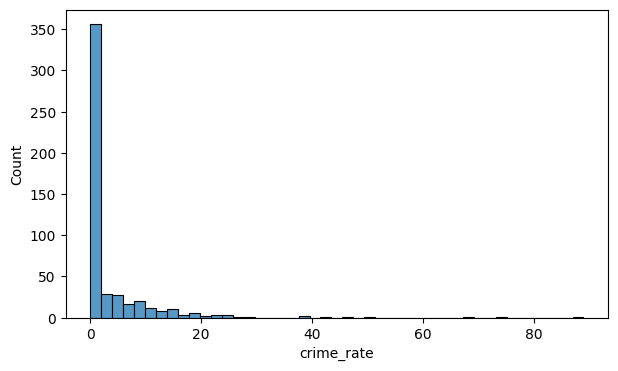

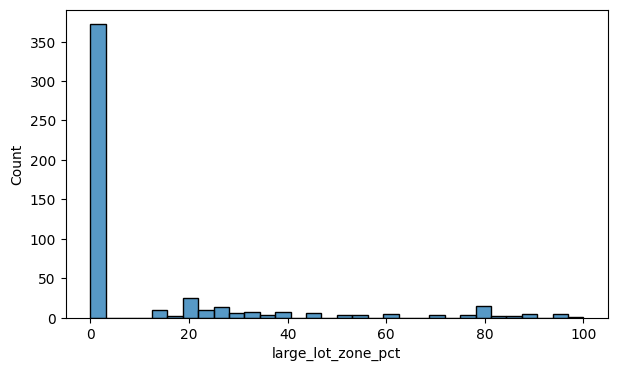

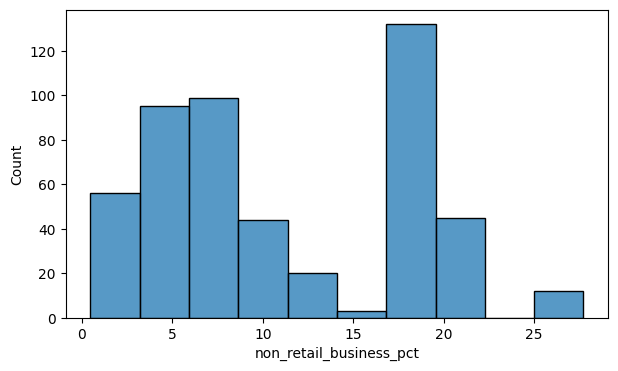

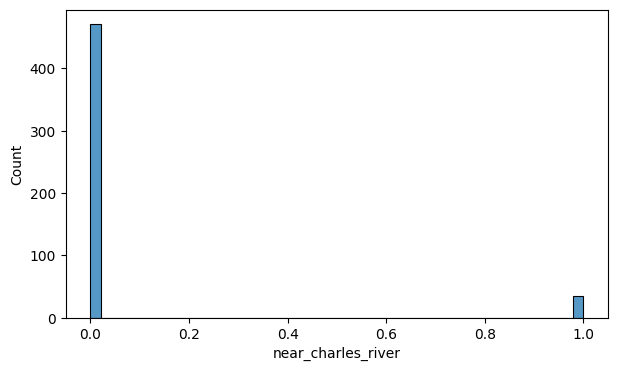

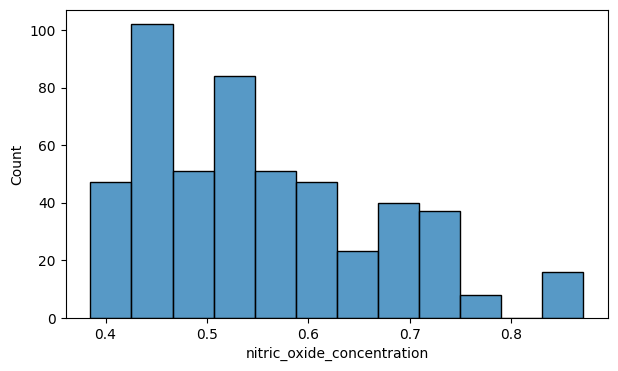

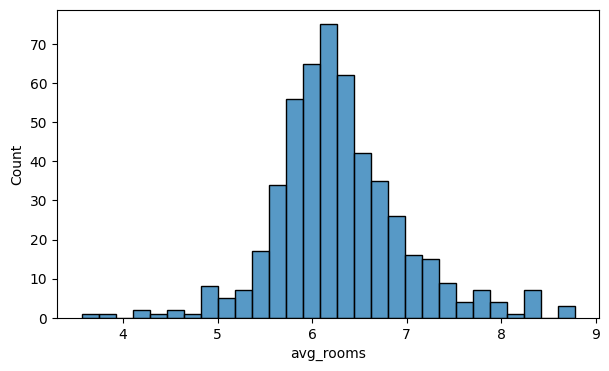

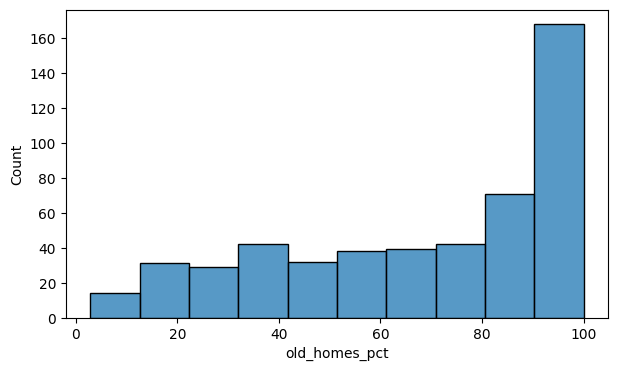

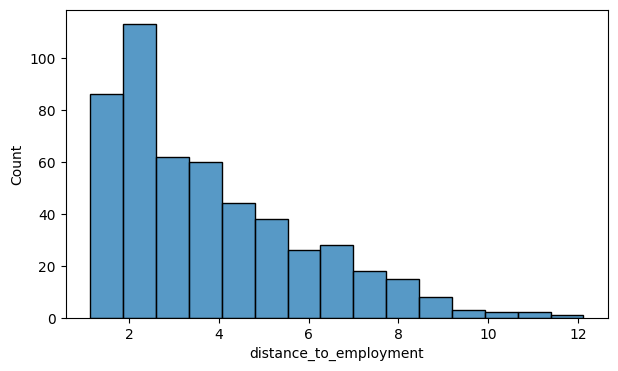

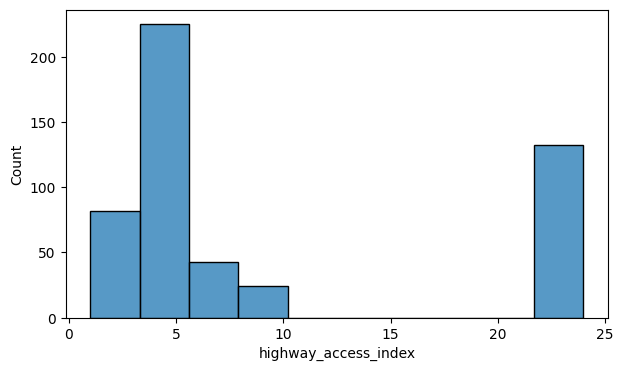

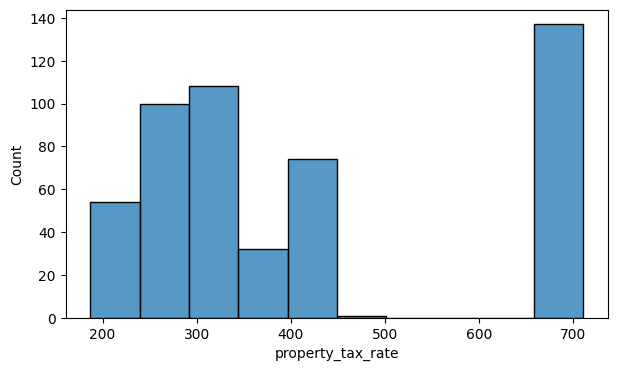

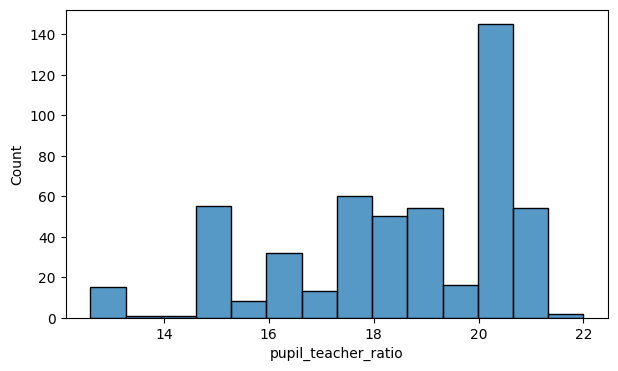

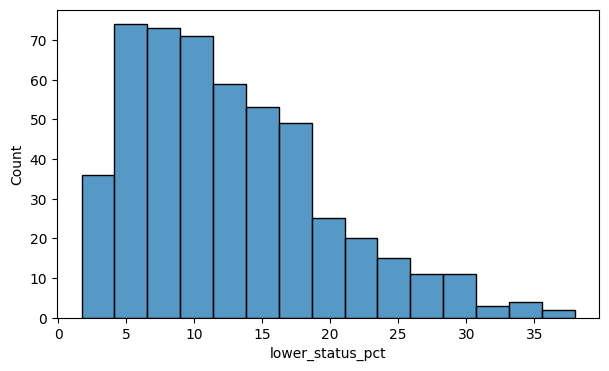

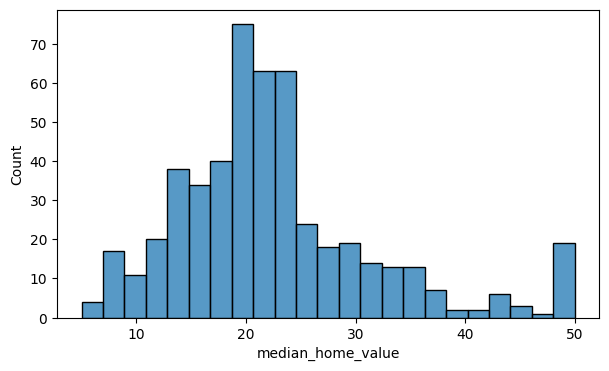

In [8]:
# let's plot all the columns to look at their distributions

import seaborn as sns

for i in df.columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=i)
    plt.show()

* Crime_rate and Large_lot_zone_pct have heavily skewed distributions.
* avg_rooms and median_home_value have close to normal distributions.

**Plot the scatterplots for features and the target variable `MEDV` and list your observations.**

In [9]:
df.columns

Index(['crime_rate', 'large_lot_zone_pct', 'non_retail_business_pct',
       'near_charles_river', 'nitric_oxide_concentration', 'avg_rooms',
       'old_homes_pct', 'distance_to_employment', 'highway_access_index',
       'property_tax_rate', 'pupil_teacher_ratio', 'lower_status_pct',
       'median_home_value'],
      dtype='str')

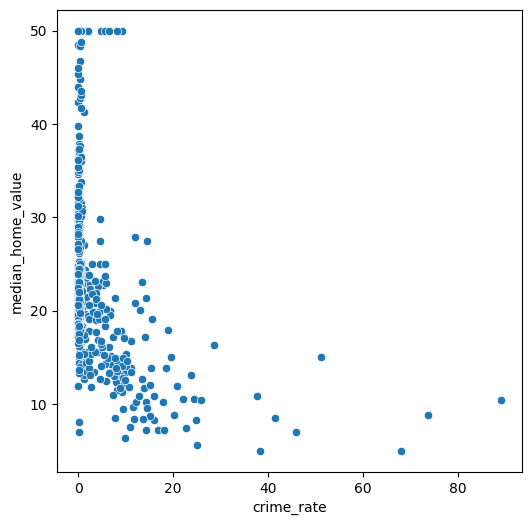

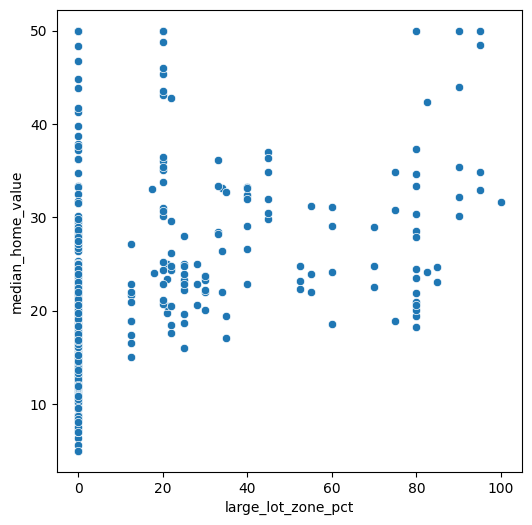

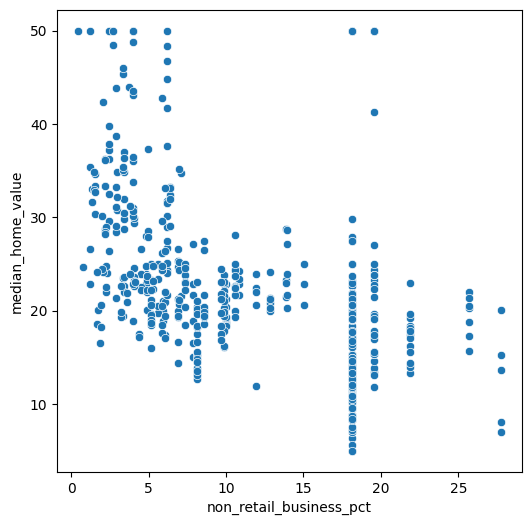

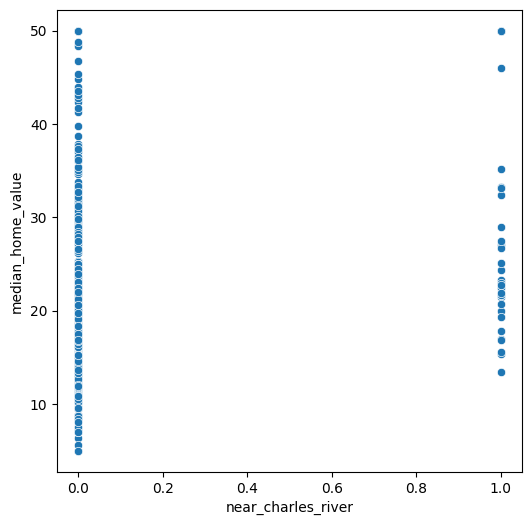

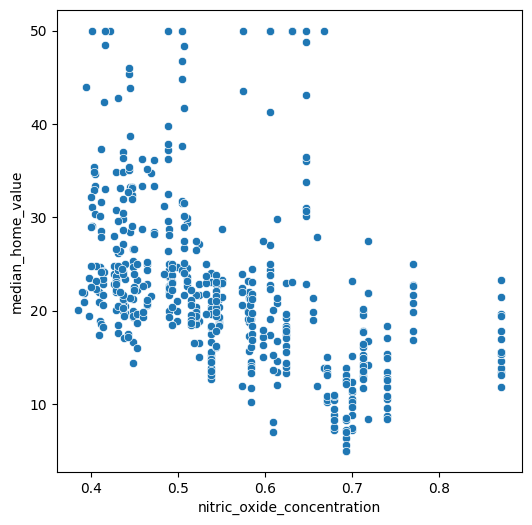

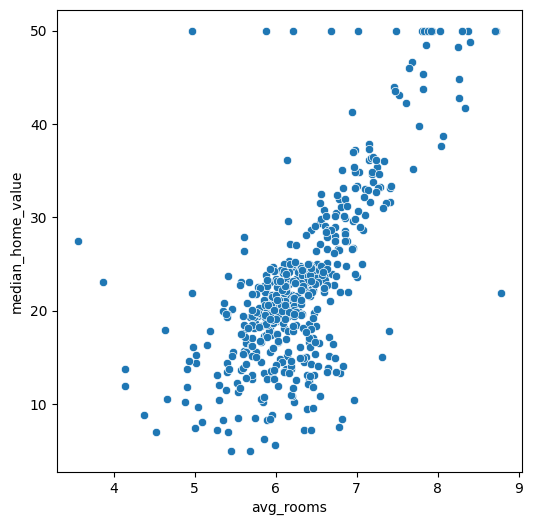

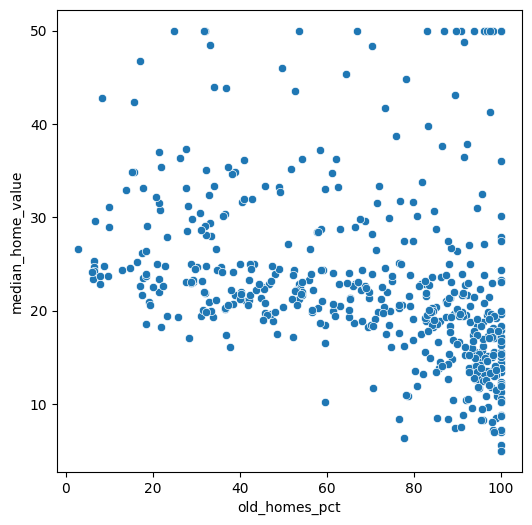

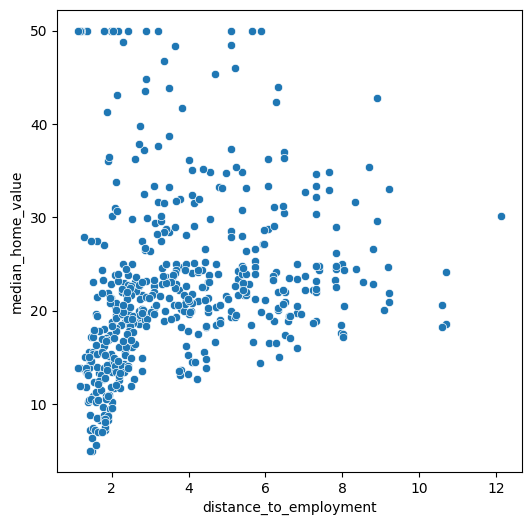

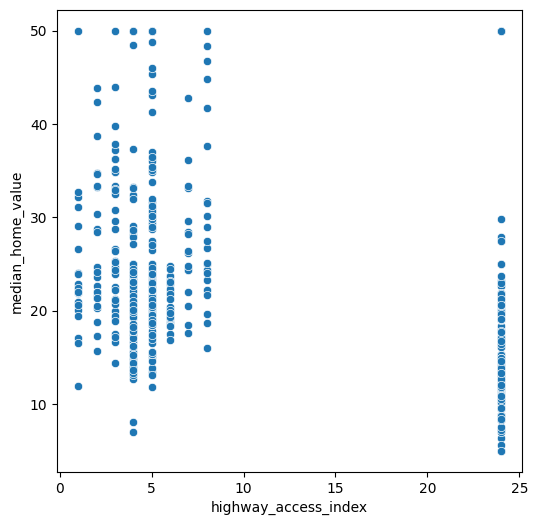

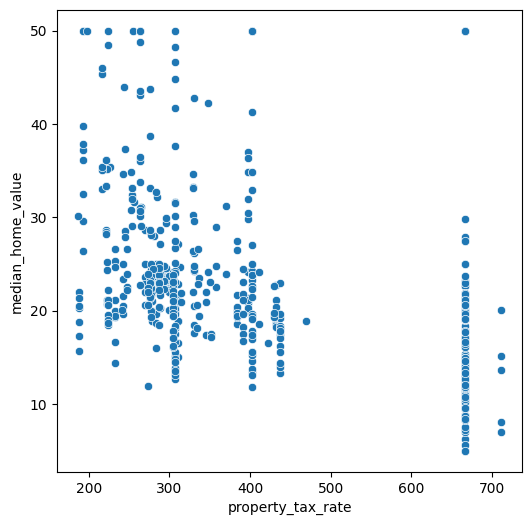

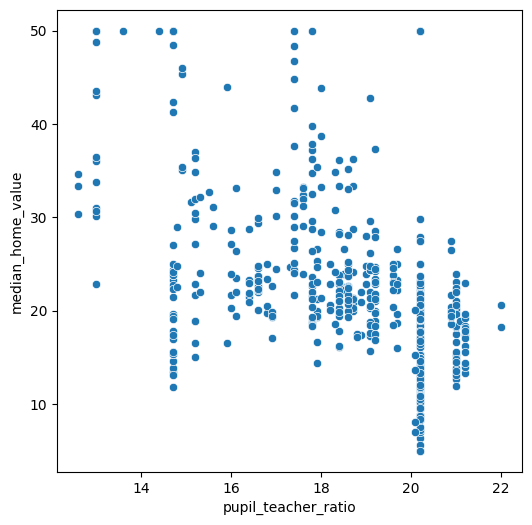

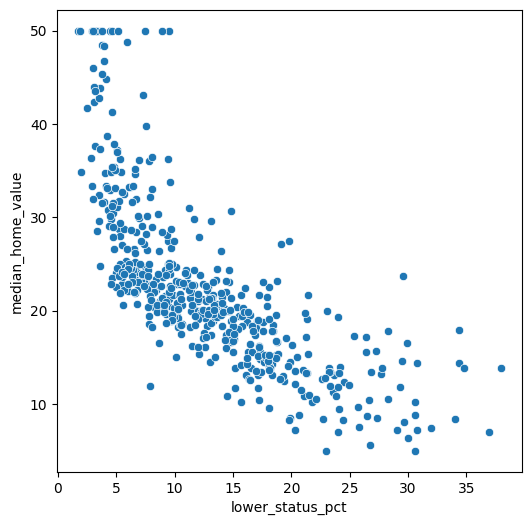

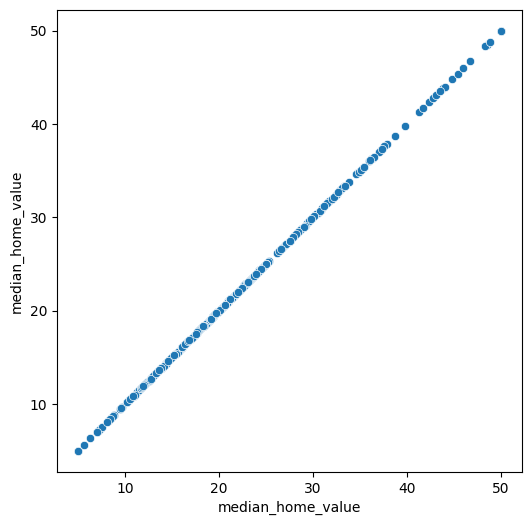

In [10]:
# let's plot the scatterplots of median price with all the features

for i in df.columns:
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=df, x=i, y="median_home_value")
    plt.show()

* lower_status_pct and avg_rooms show a slightly strong linear relationship with median_home_value.

**Plot the correlation heatmap and list your observations.**

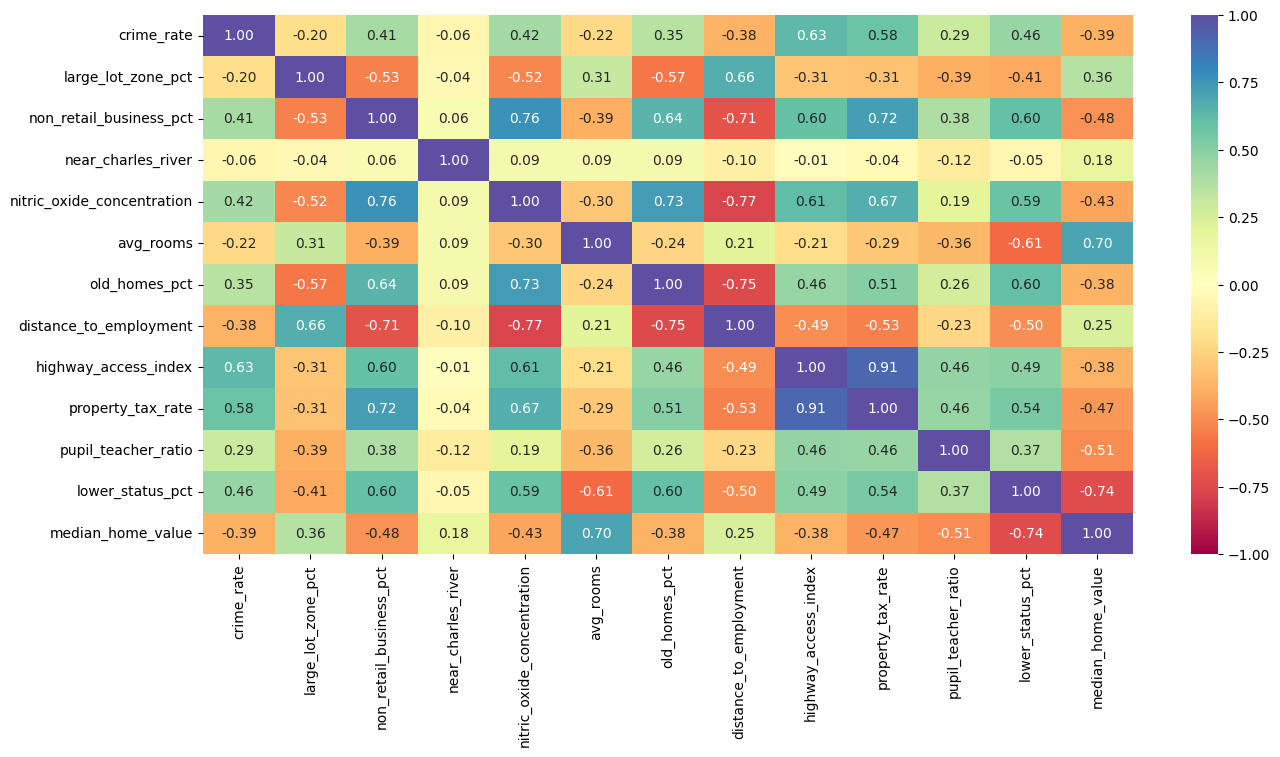

In [11]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* Nitric_oxide_concentration and property_tax_rate show a slightly strong positive linear relationship with INDUS, while DIS shows a slightly strong negative linear relationship with INDUS.
* Nitric_oxide_concentration shows a slightly strong positive linear relationship with old_homes_pct, while distance_to_employment shows a slightly strong negative linear relationship with old_homes_pct.
* avg_rooms shows a slightly strong positive linear relationship with median_home_value, while lower_status_pct shows a slightly strong negative linear relationship with median_home_value.

### Split the dataset

Split the data into the dependent and independent variables

In [12]:
# splitting the data into the dependent and independent variables
X = df.drop("median_home_value", axis=1)
y = df["median_home_value"]

# Add constant term
X = sm.add_constant(X)


### Model Building

**Make the linear model using statsmodels OLS and print the model summary.**

In [13]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      median_home_value   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          2.23e-133
Time:                        19:15:57   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

**Overall Model Fit:**

* **R-squared (0.734):** This indicates that the model explains **73.4% of the variance** in median home values. In other words, the independent variables collectively account for a substantial proportion of the variability in housing prices.

* **F-statistic (113.5) and Prob (F-statistic) (2.23e-133):** These values test the overall significance of the model. The extremely small p-value(Prob F-statistic) indicates that the model is statistically significant. This means that **at least one of the independent variables significantly affects median home value**.


**Coefficients and Significance:**

* **const (41.6173):** This is the intercept of the regression line. It represents the predicted median home value when all predictors are equal to zero (which may not be practically meaningful).

* **crime_rate (-0.1214):** Holding all other variables constant, a one-unit increase in crime rate is associated with a **decrease of 0.1214** (in $1000s) in median home value. This effect is statistically significant (p < 0.05).

* **large_lot_zone_pct (0.0470):** A one-unit increase in the percentage of large residential zoning is associated with an **increase of 0.047** (in $1000s) in median home value, holding other variables constant. This effect is statistically significant.

* **non_retail_business_pct (0.0135):** This coefficient suggests a very small positive relationship with median home value. However, the high p-value (0.829) indicates that this effect is **not statistically significant**.

* **near_charles_river (2.8400):** Homes located near the Charles River are predicted to have median home values approximately **2.84 higher** (in $1000s) than homes not near the river, holding other variables constant. This effect is statistically significant.

* **nitric_oxide_concentration (-18.7580):** A one-unit increase in pollution concentration is associated with a **decrease of 18.76** (in $1000s) in median home value. This is a large negative and statistically significant effect.

* **avg_rooms (3.6581):** Each additional room is associated with an **increase of 3.66** (in $1000s) in median home value, holding other factors constant. This is one of the strongest positive predictors and is statistically significant.

* **old_homes_pct (0.0036):** This variable has a very small coefficient and a large p-value (0.787), meaning it is **not statistically significant** in explaining median home value.

* **distance_to_employment (-1.4908):** A one-unit increase in distance to employment centers is associated with a **decrease of 1.49** (in $1000s) in median home value. This effect is statistically significant.

* **highway_access_index (0.2894):** Better highway accessibility is associated with an **increase of 0.289** (in $1000s) in median home value. This effect is statistically significant.

* **property_tax_rate (-0.0127):** Higher property tax rates are associated with a **small decrease** in median home value. This effect is statistically significant.

* **pupil_teacher_ratio (-0.9375):** A one-unit increase in pupil-teacher ratio is associated with a **decrease of 0.9375** (in $1000s) in median home value, holding other factors constant. This effect is statistically significant(p-value is less than alpha).

* **lower_status_pct (-0.5520):** A one-unit increase in the percentage of lower-status population is associated with a **decrease of 0.552** (in $1000s) in median home value. This is a strong negative and statistically significant predictor.

## Assumptions

In [14]:
# Get fitted values and residuals
fitted = model.fittedvalues
residuals = model.resid
standardized_residuals = model.get_influence().resid_studentized_internal

print("Basic outputs ready: fitted, residuals, standardized_residuals")

Basic outputs ready: fitted, residuals, standardized_residuals


**Test for Linearity**

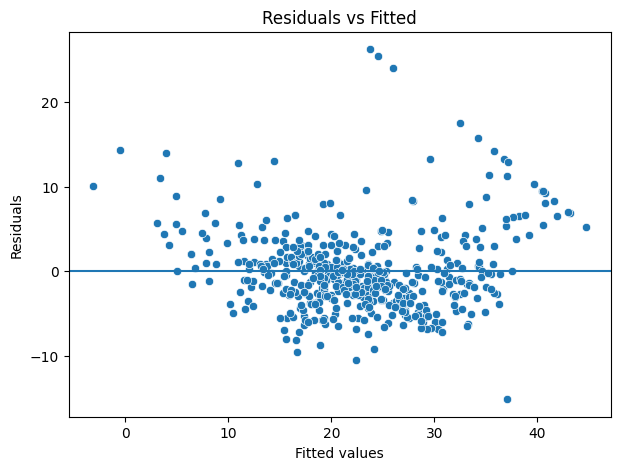

What to look for: random scatter around 0 (no curve/pattern).


In [15]:
# checking for linearity

# Plotting residuals vs fitted values
plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0)
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

print("What to look for: random scatter around 0 (no curve/pattern).")

- The residuals are randomly scattered around zero with no clear curved pattern.
- Hence, the assumptions of linearity are satisfied.

**Test for no autocorrelation**

In [16]:
from statsmodels.stats.stattools import durbin_watson

# Calculate Durbin-Watson statistic
dw_stat = durbin_watson(residuals)

print("Durbin-Watson statistic:", round(dw_stat, 3))

# Interpretation
if dw_stat < 1.5:
    print("Conclusion: Possible positive autocorrelation.")
elif dw_stat > 2.5:
    print("Conclusion: Possible negative autocorrelation.")
else:
    print("Conclusion: No strong evidence of autocorrelation.")

Durbin-Watson statistic: 1.077
Conclusion: Possible positive autocorrelation.


- The Durbin–Watson statistic is 1.077, which is below 2 and suggests possible mild positive autocorrelation. However, since the dataset is cross-sectional rather than time-series, autocorrelation is not considered a major concern in this analysis.

**Test for normality**

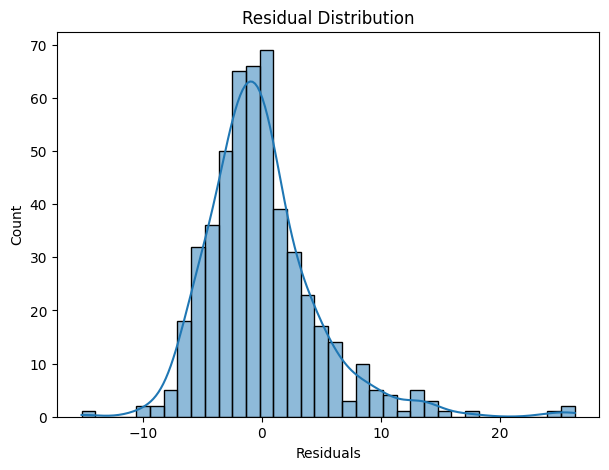

In [17]:
# checking for normality of residuals

# Histogram
plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()


- The histogram of residuals almost has a bell shape structure.
- Let's check the Q-Q plot.

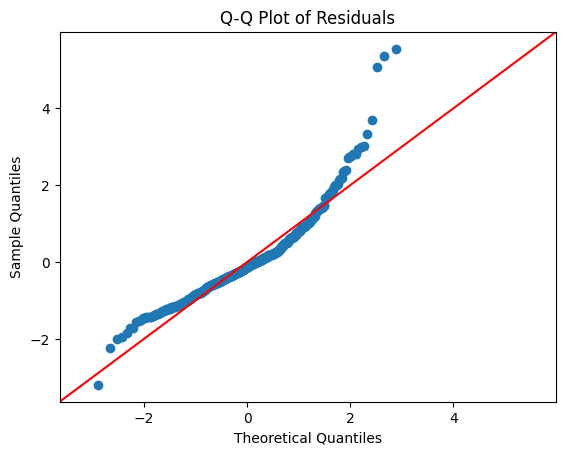

In [18]:
# Q-Q plot
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

- The residuals almost follow a straight line.
- Let's check the results of the Shapiro-Wilk test.

In [19]:
#Shapiro-Wilk test for normality
stats.shapiro(residuals)

ShapiroResult(statistic=np.float64(0.9089881332662899), pvalue=np.float64(7.592615812834763e-17))

**Observations**

- Since p-value < 0.05, the residuals are not normal as per the Shapiro-Wilk test.
- However, based on the distribution plot and Q-Q plot, we can consider the distribution to be a good approximation of the normal distribution.
- Given the large sample size (n = 506), the Central Limit Theorem ensures that the sampling distribution of the regression coefficients is approximately normal. Therefore, the inference from the model remains reliable, and the normality assumption is reasonably satisfied for practical purposes.

**Test for homoscedasticity**

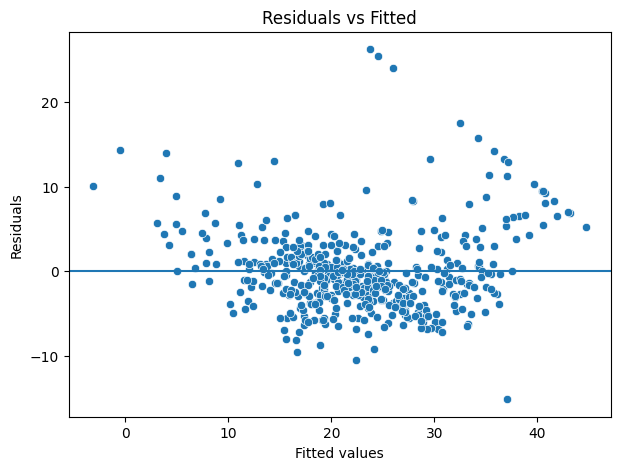

What to look for: no funnel shape (variance should be constant across fitted values).


In [20]:
# checking for homoscedasticity(constant variance)

#Plotting residuals vs fitted values again to check for homoscedasticity
plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0)
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

print("What to look for: no funnel shape (variance should be constant across fitted values).")

- The residuals versus fitted plot does not show a clear funnel shape. The spread of residuals appears relatively consistent across fitted values. This suggests that the assumption of constant variance (homoscedasticity) is reasonably satisfied.

**Test for multicollinearity**

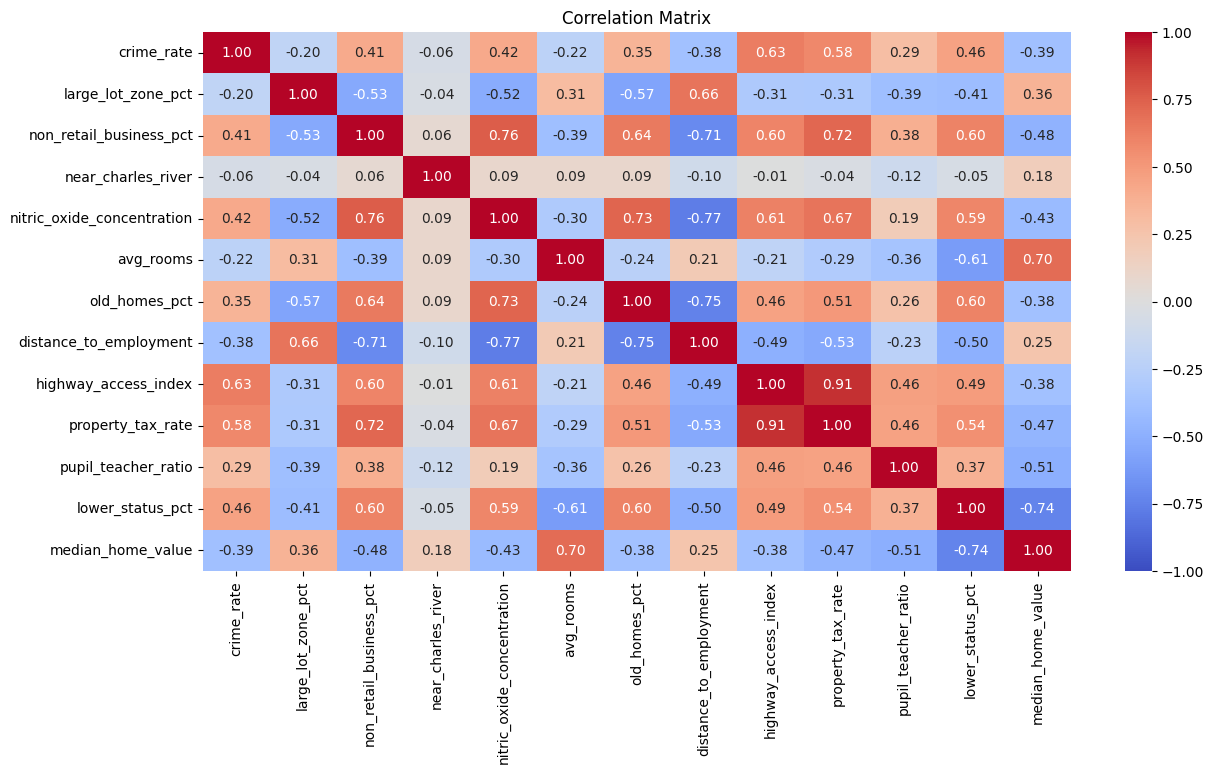

In [21]:
# checking for multicollinearity
plt.figure(figsize=(14,7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows:

- The model shows evidence of multicollinearity, particularly between highway_access_index and property_tax_rate(0.91). While this may affect the precision of some coefficient estimates, the model remains usable for explanatory purposes.

**Conclusion:**

Overall, the linear regression model satisfies the key assumptions reasonably well. The model explains approximately 73.4% of the variation in median home values and identifies several statistically significant predictors. Therefore, the model is appropriate for interpretation and analysis of the factors affecting housing prices.